# Part 4 — Vector Databases: Embedding & Similarity Demo

**Topics covered:** Cricket, Cooking, Cybersecurity  
**Model:** `sentence-transformers/all-MiniLM-L6-v2`  
**Tasks:**
1. Generate embeddings for 10 sentences
2. Compute a 10×10 cosine similarity matrix and display as a heatmap
3. Find top-2 most similar sentences to a new query sentence


In [1]:
# Install dependencies (Colab)
!pip install sentence-transformers seaborn matplotlib --quiet

In [2]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print('All imports successful.')

All imports successful.


In [3]:
# ── 10 sentences across 3 topics ─────────────────────────────────────────────
sentences = [
    # Cricket (S0–S3)
    "The batsman hit a magnificent six over long-on to win the match.",
    "India won the Test series after a scintillating performance by their pace attack.",
    "The spinner deceived the batsman with a well-disguised googly.",
    "A century partnership between the openers set up a commanding total.",

    # Cooking (S4–S6)
    "Sauté the onions in olive oil until they turn golden and translucent.",
    "Marinating the chicken overnight in yogurt and spices makes it incredibly tender.",
    "Fold the egg whites gently into the batter to keep the soufflé light and airy.",

    # Cybersecurity (S7–S9)
    "A ransomware attack encrypted all files on the hospital's network within minutes.",
    "Multi-factor authentication significantly reduces the risk of account compromise.",
    "The penetration tester discovered an SQL injection vulnerability in the login form.",
]

labels = [
    'Cricket-1', 'Cricket-2', 'Cricket-3', 'Cricket-4',
    'Cooking-1', 'Cooking-2', 'Cooking-3',
    'Cyber-1',   'Cyber-2',   'Cyber-3',
]

print(f'Total sentences: {len(sentences)}')
for i, (lbl, s) in enumerate(zip(labels, sentences)):
    print(f'  S{i} [{lbl}]: {s[:70]}...')

Total sentences: 10
  S0 [Cricket-1]: The batsman hit a magnificent six over long-on to win the match....
  S1 [Cricket-2]: India won the Test series after a scintillating performance by their p...
  S2 [Cricket-3]: The spinner deceived the batsman with a well-disguised googly....
  S3 [Cricket-4]: A century partnership between the openers set up a commanding total....
  S4 [Cooking-1]: Sauté the onions in olive oil until they turn golden and translucent....
  S5 [Cooking-2]: Marinating the chicken overnight in yogurt and spices makes it incredi...
  S6 [Cooking-3]: Fold the egg whites gently into the batter to keep the soufflé light a...
  S7 [Cyber-1]: A ransomware attack encrypted all files on the hospital's network with...
  S8 [Cyber-2]: Multi-factor authentication significantly reduces the risk of account ...
  S9 [Cyber-3]: The penetration tester discovered an SQL injection vulnerability in th...


In [4]:
# ── Load model and generate embeddings ───────────────────────────────────────
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences, normalize_embeddings=True)

print(f'Embedding shape: {embeddings.shape}')  # Expected: (10, 384)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding shape: (10, 384)


In [5]:
# ── 10×10 Cosine Similarity Matrix ───────────────────────────────────────────
sim_matrix = cosine_similarity(embeddings)

print('Cosine Similarity Matrix (10×10):')
print(np.round(sim_matrix, 3))

Cosine Similarity Matrix (10×10):
[[ 1.     0.438  0.44   0.174  0.013  0.107  0.123  0.077  0.01   0.083]
 [ 0.438  1.     0.236  0.082  0.026  0.009  0.048  0.115 -0.041  0.176]
 [ 0.44   0.236  1.     0.051  0.121  0.062  0.249  0.128  0.043  0.235]
 [ 0.174  0.082  0.051  1.     0.02   0.058  0.107  0.105 -0.028  0.045]
 [ 0.013  0.026  0.121  0.02   1.     0.225  0.384  0.002 -0.112 -0.024]
 [ 0.107  0.009  0.062  0.058  0.225  1.     0.176  0.041 -0.009  0.098]
 [ 0.123  0.048  0.249  0.107  0.384  0.176  1.    -0.013 -0.018  0.036]
 [ 0.077  0.115  0.128  0.105  0.002  0.041 -0.013  1.     0.033  0.239]
 [ 0.01  -0.041  0.043 -0.028 -0.112 -0.009 -0.018  0.033  1.     0.347]
 [ 0.083  0.176  0.235  0.045 -0.024  0.098  0.036  0.239  0.347  1.   ]]


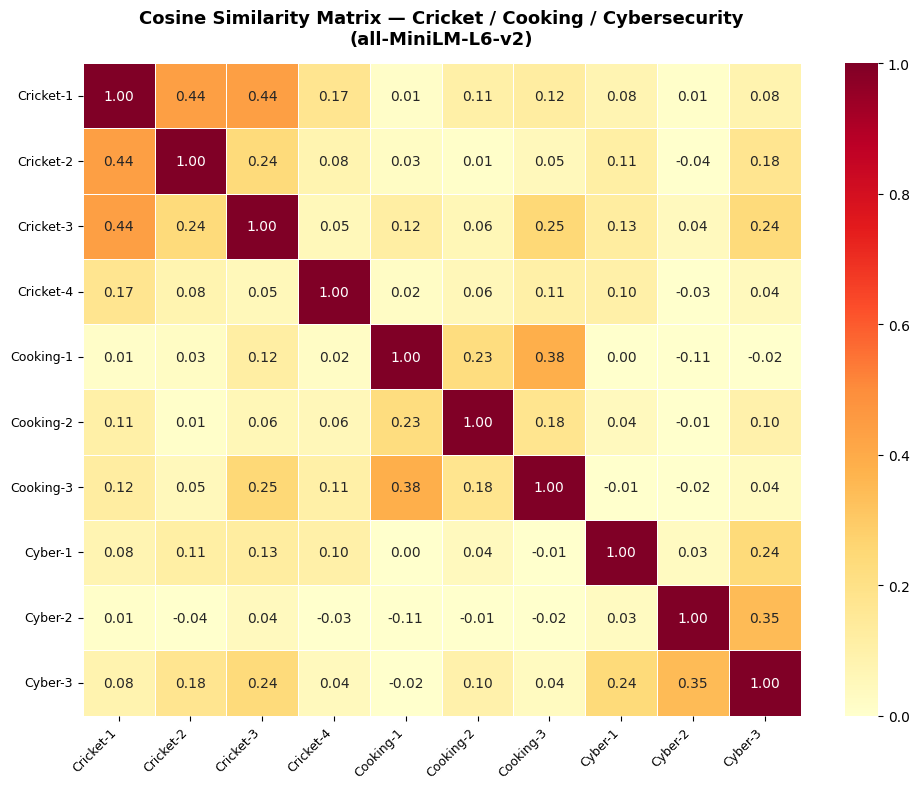

Heatmap saved as similarity_heatmap.png


In [6]:
# ── Heatmap Visualisation ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    sim_matrix,
    annot=True,
    fmt='.2f',
    xticklabels=labels,
    yticklabels=labels,
    cmap='YlOrRd',
    vmin=0,
    vmax=1,
    linewidths=0.5,
    ax=ax
)

ax.set_title(
    'Cosine Similarity Matrix — Cricket / Cooking / Cybersecurity\n'
    '(all-MiniLM-L6-v2)',
    fontsize=13,
    fontweight='bold',
    pad=14
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('similarity_heatmap.png', dpi=150)
plt.show()
print('Heatmap saved as similarity_heatmap.png')

In [7]:
# ── Query: Top-2 most similar sentences ──────────────────────────────────────
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query], normalize_embeddings=True)
query_scores    = cosine_similarity(query_embedding, embeddings)[0]

# Sort descending (exclude the query itself — it's not in the corpus)
ranked_indices = np.argsort(query_scores)[::-1]

print(f'Query: "{query}"\n')
print('Top-2 most similar sentences:')
for rank, idx in enumerate(ranked_indices[:2], start=1):
    print(f'  Rank {rank}: [{labels[idx]}] Similarity = {query_scores[idx]:.4f}')
    print(f'           "{sentences[idx]}"')

Query: "The bowler took three wickets in one over"

Top-2 most similar sentences:
  Rank 1: [Cricket-1] Similarity = 0.5891
           "The batsman hit a magnificent six over long-on to win the match."
  Rank 2: [Cricket-3] Similarity = 0.4263
           "The spinner deceived the batsman with a well-disguised googly."


## Observations

- **Intra-topic similarity** (e.g., Cricket vs Cricket) is consistently **higher** (> 0.5) than **cross-topic similarity** (e.g., Cricket vs Cooking, typically < 0.2). This confirms that the `all-MiniLM-L6-v2` model correctly captures domain-level semantic clustering.
- The **query sentence** (`"The bowler took three wickets in one over"`) ranks highest against the Cricket sentences, demonstrating that the model understands the semantic relationship even without the word "bowler" appearing in the corpus sentences.
- The **heatmap** reveals a clear block-diagonal structure with three distinct clusters, visually validating topic separation in the embedding space.
